# Specific Stock Simulation


In [10]:
import matplotlib.pyplot as plt
import analysis_interfaces.interface_specific_stock as iss


## Block 1: Parameters


In [11]:
ticker = "NVDA"
initial_funds = 100
include_fundamentals = True
include_sentiment = False  # True requires API keys and adds latency

period = "max"  # Valid periods: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max

## Block 4: Simulate Daily Buy/Sell/Hold Strategy


In [12]:
df_pred = iss.build_prediction_and_stats(
            ticker,
            include_sentiment=include_sentiment,
            period=period,
        )

In [13]:
simulation_result = iss.simulate_prediction_signal_strategy(
    df_pred,
    initial_funds=initial_funds,
)


## Block 5: Portfolio Summary


In [14]:
df_pred

,Date,Open,High,Low,Close,Adj Close,Volume,TICKER,SMA10,SMA20,...,Daily_Return,Cumulative_Return,Daily Gain/Loss,technical_analysis_buy_score,technical_analysis_sell_score,fundamental_analysis_score,sentiment_analysis_score,multifactor_analysis_score,Signal,Signal_Text
0,2026-03-16,182.970001,185.050003,182.874405,184.170593,184.170593,75321975,NVDA,NaN,NaN,...,NaN,NaN,1.200592,0.00,-0.10,0.3375,0.0,0.294,0.138833,WEAK BUY
1,2026-03-13,184.919998,186.089996,179.940002,180.250000,180.250000,160513800,NVDA,NaN,NaN,...,-0.021288,-0.021288,-4.669998,0.10,-0.45,0.3375,0.0,0.294,0.072167,HOLD
2,2026-03-12,184.050003,184.940002,181.750000,183.139999,183.139999,155762700,NVDA,NaN,NaN,...,0.016033,-0.005596,-0.910004,0.00,-0.55,0.3375,0.0,0.294,0.018833,HOLD
3,2026-03-11,185.910004,187.619995,184.449997,186.029999,186.029999,145280400,NVDA,NaN,NaN,...,0.015780,0.010096,0.119995,0.00,-0.55,0.3375,0.0,0.294,0.018833,HOLD
4,2026-03-10,182.399994,186.440002,182.009995,184.770004,184.760010,179118500,NVDA,NaN,NaN,...,-0.006773,0.003255,2.370010,0.20,-0.35,0.3375,0.0,0.294,0.125500,WEAK BUY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6823,1999-01-28,0.041667,0.041927,0.041276,0.041536,0.038080,227520000,NVDA,0.039414,0.041823,...,0.049339,-0.999774,-0.000131,0.25,-0.50,0.3375,0.0,0.294,0.098833,HOLD
6824,1999-01-27,0.041927,0.042969,0.039583,0.041667,0.038200,244368000,NVDA,0.039792,0.041510,...,0.003154,-0.999774,-0.000260,0.25,-0.50,0.3375,0.0,0.294,0.098833,HOLD
6825,1999-01-26,0.045833,0.046745,0.041146,0.041797,0.038319,343200000,NVDA,0.040143,0.041126,...,0.003120,-0.999773,-0.004036,0.25,-0.50,0.3375,0.0,0.294,0.098833,HOLD
6826,1999-01-25,0.044271,0.045833,0.041016,0.045313,0.041542,510480000,NVDA,0.040690,0.041100,...,0.084121,-0.999754,0.001042,0.25,-0.50,0.3375,0.0,0.294,0.098833,HOLD


In [15]:
simulation_result["transactions"]


,Date,action,signal_text,trade_price,units,trade_value,cash_balance,units_held,portfolio_value
0,1999-01-22,BUY,WEAK BUY,0.042383,117.971828,5.0,95.0,117.971828,99.838733
1,1999-02-02,BUY,WEAK BUY,0.038411,130.169351,5.0,90.0,248.141178,99.240777
2,1999-02-03,BUY,WEAK BUY,0.037370,133.797163,5.0,85.0,381.938342,99.521677
3,1999-02-04,BUY,WEAK BUY,0.039323,127.152048,5.0,80.0,509.090389,100.416562
4,1999-02-08,BUY,WEAK BUY,0.040690,122.880317,5.0,75.0,631.970706,100.180240
5,1999-02-09,BUY,WEAK BUY,0.039453,126.733075,5.0,70.0,758.703781,99.043940
6,1999-02-10,BUY,WEAK BUY,0.038086,131.281833,5.0,65.0,889.985614,98.722445
7,1999-02-11,BUY,WEAK BUY,0.039583,126.315262,5.0,60.0,1016.300876,101.816715
8,1999-02-12,BUY,WEAK BUY,0.042578,117.430159,5.0,55.0,1133.731036,104.305963
9,1999-02-16,BUY,WEAK BUY,0.044010,113.609254,5.0,50.0,1247.340289,104.571137


In [16]:
simulation_result["summary"]


,start_date,end_date,initial_funds,ending_cash_balance,units_held,average_cost_per_unit,latest_close,holdings_value,total_portfolio_value,profit_loss,profit_loss_pct,buy_transactions,sell_transactions
0,1999-01-22,2026-03-16,100.0,0.0,2347.405257,0.0426,184.170593,432323.018751,432323.018751,432223.018751,432223.018751,20,0


## Block 6: Consolidated Chart


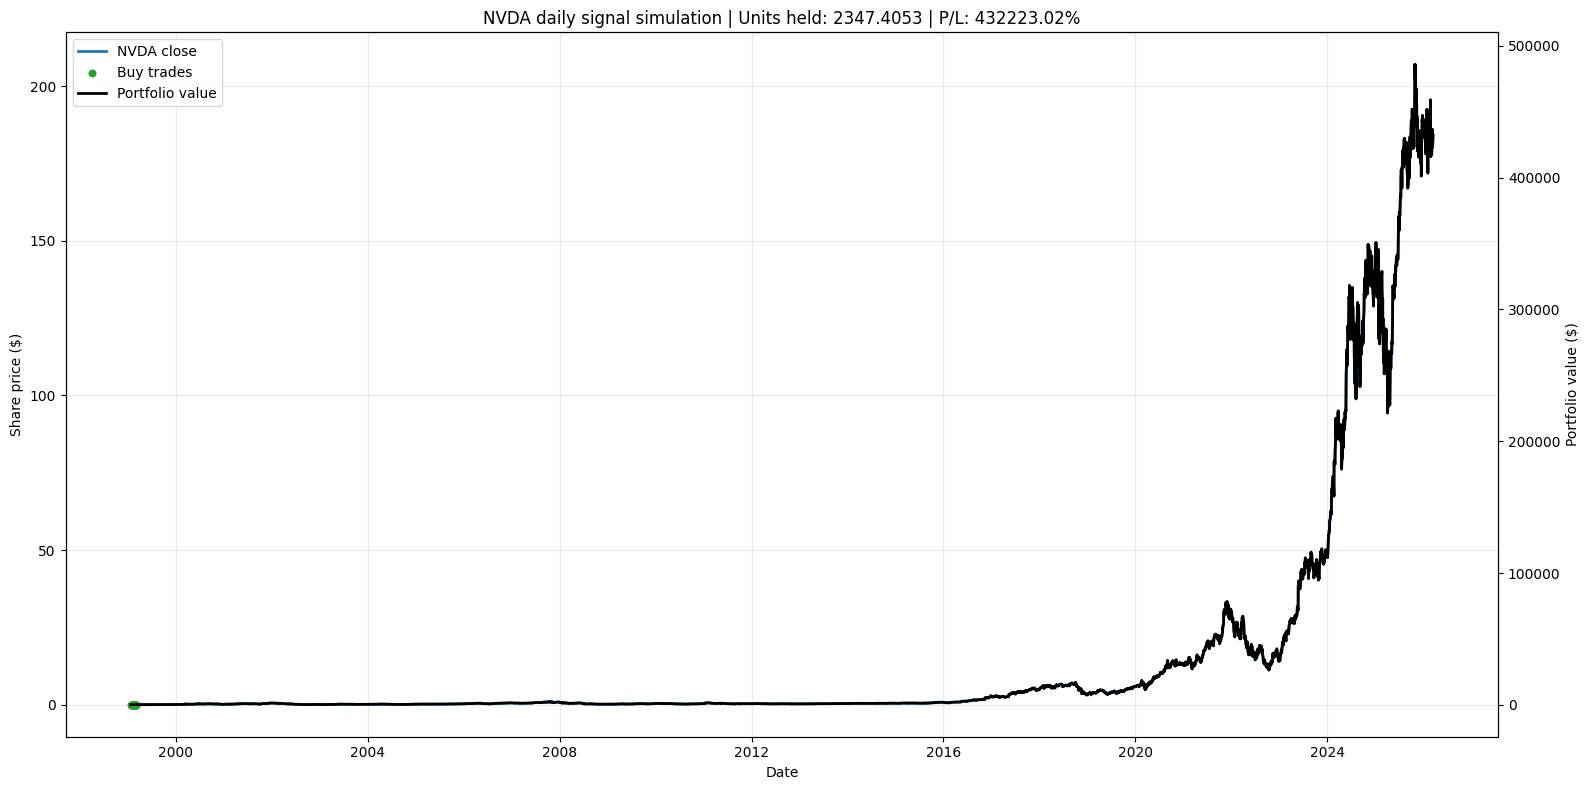

In [17]:
price_history = simulation_result["price_history"].copy()
daily_history = simulation_result["daily_history"].copy()
transactions = simulation_result["transactions"].copy()
simulation_summary = simulation_result["summary"].iloc[0]

buy_txns = transactions[transactions["action"] == "BUY"].copy()
sell_txns = transactions[transactions["action"] == "SELL"].copy()

fig, ax_price = plt.subplots(figsize=(16, 8))
ax_price.plot(
    price_history["Date"],
    price_history["Close"],
    color="#1f77b4",
    linewidth=2,
    label=f"{ticker} close",
)

if not buy_txns.empty:
    ax_price.scatter(
        buy_txns["Date"],
        buy_txns["trade_price"],
        color="#2ca02c",
        marker=".",
        s=90,
        label="Buy trades",
        zorder=5,
    )

if not sell_txns.empty:
    ax_price.scatter(
        sell_txns["Date"],
        sell_txns["trade_price"],
        color="#d62728",
        marker=".",
        s=90,
        label="Sell trades",
        zorder=5,
    )

ax_price.set_xlabel("Date")
ax_price.set_ylabel("Share price ($)")
ax_price.grid(alpha=0.25)

ax_portfolio = ax_price.twinx()
ax_portfolio.plot(
    daily_history["Date"],
    daily_history["portfolio_value"],
    color="#000000",
    linewidth=2,
    label="Portfolio value",
)
ax_portfolio.set_ylabel("Portfolio value ($)")

title = (
    f"{ticker} daily signal simulation | "
    f"Units held: {simulation_summary['units_held']:.4f} | "
    f"P/L: {simulation_summary['profit_loss_pct']:.2f}%"
)
ax_price.set_title(title)

handles_price, labels_price = ax_price.get_legend_handles_labels()
handles_portfolio, labels_portfolio = ax_portfolio.get_legend_handles_labels()
ax_price.legend(handles_price + handles_portfolio, labels_price + labels_portfolio, loc="upper left")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Block 7: Daily Portfolio History


In [18]:
simulation_result["daily_history"][[
    "Date",
    "signal_text",
    "action",
    "trade_units",
    "trade_value",
    "cash_balance",
    "units_held",
    "holdings_value",
    "portfolio_value",
    "profit_loss_pct",
]]


,Date,signal_text,action,trade_units,trade_value,cash_balance,units_held,holdings_value,portfolio_value,profit_loss_pct
0,1999-01-22,WEAK BUY,BUY,117.971828,5.0,95.0,117.971828,4.838733,99.838733,-0.161267
1,1999-01-25,HOLD,HOLD,0.000000,0.0,95.0,117.971828,5.345658,100.345658,0.345658
2,1999-01-26,HOLD,HOLD,0.000000,0.0,95.0,117.971828,4.930869,99.930869,-0.069131
3,1999-01-27,HOLD,HOLD,0.000000,0.0,95.0,117.971828,4.915532,99.915532,-0.084468
4,1999-01-28,HOLD,HOLD,0.000000,0.0,95.0,117.971828,4.900078,99.900078,-0.099922
...,...,...,...,...,...,...,...,...,...,...
6823,2026-03-10,WEAK BUY,HOLD,0.000000,0.0,0.0,2347.405257,433730.079309,433730.079309,433630.079309
6824,2026-03-11,HOLD,HOLD,0.000000,0.0,0.0,2347.405257,436687.797037,436687.797037,436587.797037
6825,2026-03-12,HOLD,HOLD,0.000000,0.0,0.0,2347.405257,429903.797278,429903.797278,429803.797278
6826,2026-03-13,HOLD,HOLD,0.000000,0.0,0.0,2347.405257,423119.797519,423119.797519,423019.797519
